In [3]:
import ibis
from utils.f_0_dirs import get_data_dirs

# ---

table_panel_name = "working_yearly_with_tfp_wave"
table_distance_name = "working_distance_ttwa_km"

# ---

dirs = get_data_dirs(segment="model")
con = ibis.duckdb.connect(dirs.db_path)
print(con.list_tables())
t_panel = con.table(table_panel_name)
t_distance = con.table(table_distance_name)

['fame_fixed_filtered', 'fame_yearly_kp', 'ref_ons_postcode', 'ref_ons_ttwa_name', 'working_distance_pc_', 'working_distance_ttwa_km', 'working_fixed', 'working_yearly', 'working_yearly_with_tfp_wave']


# Calculating distance-weighted TFP

We need to calculate
$$
Z_t = \sum_{j \neq i} f(d_{ij})\cdot z_{jt}
$$
For every firm-year entry in working_yearly, calculate all its peers which have tfp entries for that year, and then multiply those tfp entries by weighted distance.
This is for use in the two regressions:
$$
\begin{align*}
z_{it} &= \alpha_i + \gamma_t + \rho \sum_{j \neq i} f(d_{ij}) \cdot z_{jt} + \epsilon_{it}   \\
y_{it} &= \alpha_i + \gamma_t + \beta_1 k_{it} + \beta_2 l_{it} + \rho \sum_{j \neq i} w_{ij} z_{jt} + \epsilon_{it}
\end{align*}
$$
### Computation
- 750 million distances, 150,000 firms. Approx: 7 years per firm = possible scalar of 7 million on each distance -> 1 minute processing time

## Distance decay
- Inverse Distance ($1/d$): The standard gravity model approach. It assumes a smooth, gradual decay of interaction.
- Inverse Squared Distance ($1/d^2$): Penalizes distance much more harshly. Heavily used in New Economic Geography (NEG) to model transport costs.
- Exponential Decay ($e^{-\delta d}$): The effect drops off very rapidly but never mathematically hits absolute zero  
Normalise: sum product of transformed distances and productivities, and then divide by the total sum of transformed distances

In [ ]:
from ibis import _

# TODO: Keep industry SIC codes and use them as a 1 0 column for distance weighting product
const_d = 1000  # Example constant to divide by for exponential decay
t_panel_skinny = t_panel.select(["registered_number", "year", "tfp"])

# 1a. Distance setup (based on target firms)
t_distance_short = (
    t_distance
    .inner_join(t_panel_skinny, _.firm_i == t_panel_skinny.registered_number)
    .mutate(
        d1 = 1 / (_.distance_meters + 1),
        d2 = 1 / (_.distance_meters + 1) ** 2,
        d3 = (-_.distance_meters / const_d).exp()
    )
)

# 1b. Peer panel setup
t_panel_peer = t_panel_skinny.select(
    firm_j="registered_number",
    peer_year="year",
    peer_tfp="tfp"
)

# 2. Join peer data, matching on firm ID and year
# For every distance record
t_distance_tfp = (
    t_distance_short
    .left_join(
        t_panel_peer, 
        (_.firm_j == t_panel_peer.firm_j) & (_.year == t_panel_peer.peer_year)
    )
    .filter(_.peer_tfp.notnull())
    .mutate(
        tfp_w1=_.peer_tfp * _.d1,
        tfp_w2=_.peer_tfp * _.d2,
        tfp_w3=_.peer_tfp * _.d3
    )
    .group_by("firm_i", "year")
    .aggregate(
        tfp_wav1=_.tfp_w1.sum() / _.d1.sum(),
        tfp_wav2=_.tfp_w2.sum() / _.d2.sum(),
        tfp_wav3=_.tfp_w3.sum() / _.d3.sum(),
        nb_peers=_.peer_tfp.count()
    )
)

t_panel_tfpd = (
    t_panel
    .left_join(
        t_distance_tfp, 
        (_.registered_number == t_distance_tfp.firm_i) & (_.year == t_distance_tfp.year),
        rname="{name}_dist"
    )
    .drop(["firm_i", "year_dist"])
    # .order_by(ibis.random())
)

df_peers = (
    t_panel_tfpd
    .select(['registered_number', 'year', 'tfp', 'tfp_wav1', 'tfp_wav2', 'tfp_wav3', 'nb_peers'])
)

In [15]:
from ibis import _, selectors as s
import pandas as pd

# 1. Execute the native Ibis aggregation (returns a single wide row)
raw_result = (
    df_peers
    .select('tfp', 'tfp_wav1', 'tfp_wav2', 'tfp_wav3', 'nb_peers')
    .aggregate(
        s.across(
            s.all(),
            {
                "count": _.count(),
                "mean": _.mean(),
                "median": _.median(),
                "min": _.min(),
                "max": _.max(),
                "std": _.std(),
            }
        )
    )
    .execute()
)

# 2. Reshape the single row into a MultiIndex Series, then unstack
s_flat = raw_result.iloc[0]
s_flat.index = pd.MultiIndex.from_tuples(
    [col.rsplit("_", 1) for col in s_flat.index], 
    names=["variable", "metric"]
)

# 3. Pivot the metrics into separate columns
df_count = (
    s_flat
    .unstack(level="metric")[["count", "mean", "median", "min", "max", "std"]]
    # .transpose()
    # .reset_index()
    # .rename(columns={"index": "variable"})
)

display(df_count.style.format({
    "count": "{:,.0f}",
    "mean": "{:,.3f}",
    "median": "{:,.3f}",
    "min": "{:,.3f}",
    "max": "{:,.3f}",
    "std": "{:,.3f}"
}))

metric,count,mean,median,min,max,std
variable,,,,,,
nb_peers,"1,067,013","1,989.706",131.000,1.000,"140,608.000","5,530.584"
tfp,"1,081,520",3.014,3.023,0.001,11.592,0.677
tfp_wav1,"1,067,013",3.046,3.047,0.010,10.031,0.379
tfp_wav2,"1,067,013",3.043,3.040,0.005,10.314,0.443
tfp_wav3,"1,067,013",3.036,3.031,0.010,8.998,0.259


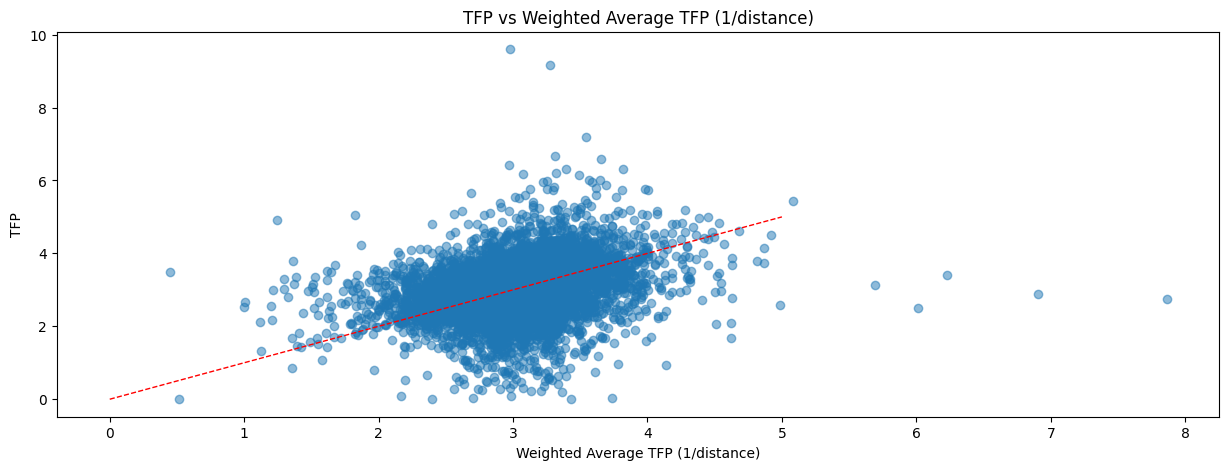

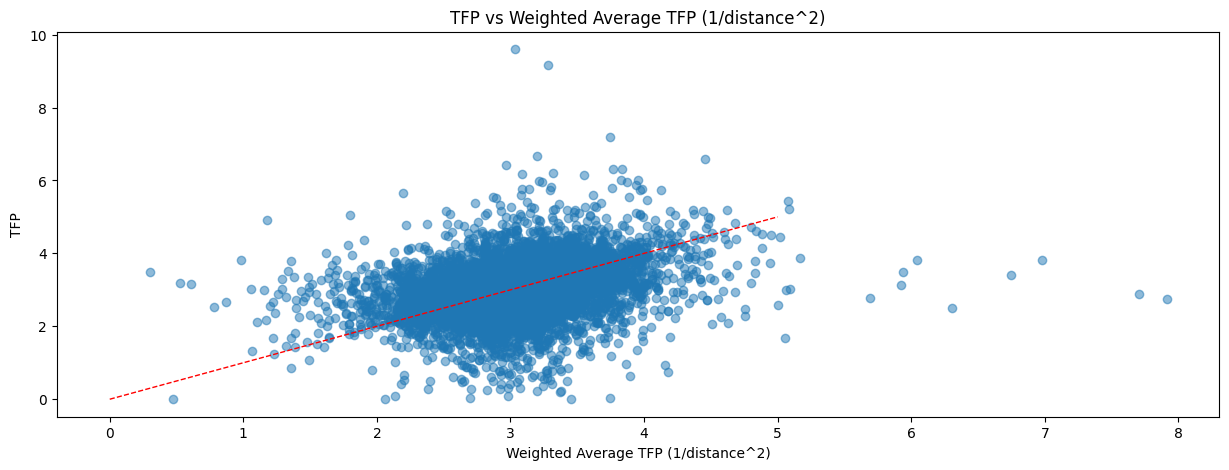

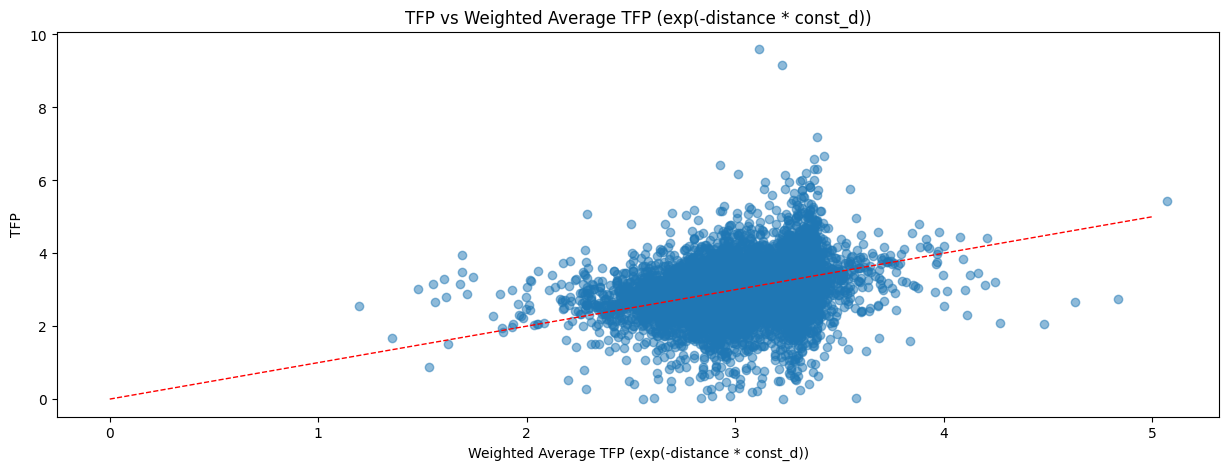

In [ ]:
# Plot 3 scatter plots where Y is tfp
# And respectively, X is tfp_wav1, tfp_wav2, tfp_wav3
# There should be 150,000 datapoints. This is too many, so we will sample 1,000 points for each plot
# In memory, as the dataframe is already executed
import matplotlib.pyplot as plt

sample_size = 10000
df_sample = df_peers.sample(n=sample_size, random_state=42)

plt.figure(figsize=(15, 5))
plt.scatter(df_sample['tfp_wav1'], df_sample['tfp'], alpha=0.5)
plt.title('TFP vs Weighted Average TFP (1/distance)')
plt.xlabel('Weighted Average TFP (1/distance)')
plt.ylabel('TFP')
plt.plot([0, 5], [0, 5], color='red', linestyle='--', linewidth=1)
plt.show()

plt.figure(figsize=(15, 5))
plt.scatter(df_sample['tfp_wav2'], df_sample['tfp'], alpha=0.5)
plt.title('TFP vs Weighted Average TFP (1/distance^2)')
plt.xlabel('Weighted Average TFP (1/distance^2)')
plt.ylabel('TFP')
plt.plot([0, 5], [0, 5], color='red', linestyle='--', linewidth=1)
plt.show()

plt.figure(figsize=(15, 5))
plt.scatter(df_sample['tfp_wav3'], df_sample['tfp'], alpha=0.5)
plt.title('TFP vs Weighted Average TFP (exp(-distance * const_d))')
plt.xlabel('Weighted Average TFP (exp(-distance * const_d))')
plt.ylabel('TFP')
plt.plot([0, 5], [0, 5], color='red', linestyle='--', linewidth=1)
plt.show()

In [ ]:
con.create_table("working_yearly_d_peers", t_panel_tfpd, overwrite=True)

DatabaseTable: fame_data.main.working_yearly_with_tfp_wave
  registered_number   string
  year                int64
  employees           int64
  fixed_total         float64
  total_assets        float64
  average_wage        float64
  gva1                float64
  gva2                float64
  gva1_per_worker     float64
  gva2_per_worker     float64
  tfp                 float64
  peer_tfp_pc8        float64
  peer_tfp_pc4_donut  float64
  peer_tfp_ttwa_donut float64
  tfp_wav1            float64
  tfp_wav2            float64
  tfp_wav3            float64
  nb_peers            int64